# 03 · Instant prediction & validation

The trained models let us predict the recommended controller and its metrics in **milliseconds**, skipping the full simulation. Here we load the saved models, predict on example plants, and **validate** the predictions against the exact comparison — the ground truth the models were trained to imitate.

In [1]:
# Make the controlbench package importable when running from notebooks/
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from controlbench.analysis import PlantModel
from controlbench.compare import compare_controllers
from controlbench.ml import load_models, predict, random_stable_plant

In [3]:
models = load_models(Path('..') / 'models')
print('loaded models; features:', models['features'])

loaded models; features: ['order', 'damping_ratio', 'natural_frequency', 'dc_gain', 'den_a1', 'den_a2', 'den_a3', 'num_s', 'num_1']


### Predict on a few textbook plants

In [4]:
examples = {
    '1/(s^2+0.4s+1)':  ([1], [1, 0.4, 1]),
    '1/(s+1)^3':       ([1], [1, 3, 3, 1]),
    '1/(s^2+3s+2)':    ([1], [1, 3, 2]),
}
for name, (num, den) in examples.items():
    plant = PlantModel(num, den)
    pred = predict(plant, models)
    print(f'{name:18} -> {pred["recommended_controller"]:5}'
          f'  settling~{pred["predicted_settling_time"]:.2f}s'
          f'  overshoot~{pred["predicted_overshoot"]:.1f}%')

1/(s^2+0.4s+1)     -> P      settling~33.20s  overshoot~35.2%


1/(s+1)^3          -> PID    settling~13.64s  overshoot~21.8%


1/(s^2+3s+2)       -> PID    settling~17.28s  overshoot~0.2%


### Predicted vs actual over a fresh test set
We draw new random plants (unseen), predict with the ML models, and compare against the exact comparison. Points on the diagonal mean the fast predictor agrees with the full simulator.

In [5]:
rng = np.random.default_rng(123)
rows = []
for _ in range(150):
    plant = random_stable_plant(rng)
    ranked, _, _ = compare_controllers(plant)
    best = ranked[0]
    if not best.metrics.stable:
        continue
    pred = predict(plant, models)
    rows.append({
        'true_ctrl': best.name, 'pred_ctrl': pred['recommended_controller'],
        'true_settle': best.metrics.settling_time, 'pred_settle': pred['predicted_settling_time'],
        'true_over': best.metrics.overshoot, 'pred_over': pred['predicted_overshoot'],
    })
test = pd.DataFrame(rows)
acc = (test['true_ctrl'] == test['pred_ctrl']).mean()
print(f'controller accuracy on fresh plants: {acc:.3f}  (n={len(test)})')

controller accuracy on fresh plants: 0.920  (n=150)


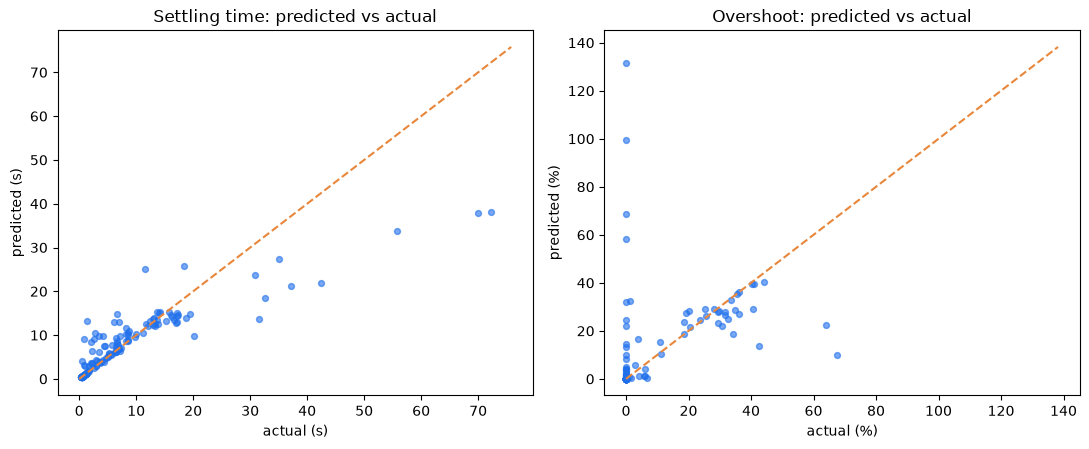

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for a, col, title, unit in [(ax[0], 'settle', 'Settling time', 's'),
                            (ax[1], 'over', 'Overshoot', '%')]:
    t, p = test['true_' + col], test['pred_' + col]
    a.scatter(t, p, s=18, alpha=0.6, color='#1f6feb')
    lim = [0, max(t.max(), p.max()) * 1.05]
    a.plot(lim, lim, '--', color='#e8873b')
    a.set_xlabel(f'actual ({unit})'); a.set_ylabel(f'predicted ({unit})')
    a.set_title(f'{title}: predicted vs actual')
plt.tight_layout(); plt.show()

Because every prediction can be checked against the exact simulator, model quality is easy to monitor: large, systematic deviations flag regions of the input space where the dataset should be enriched and the models retrained.